# Kapitel 5 - Koduppgift 7: Kodexempel genomgång

I denna uppgift går vi igenom samtliga kodexempel från kapitel 5 om dimensionsreducering.

## Importera nödvändiga bibliotek

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA, KernelPCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs, load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Sätt stil för plots
plt.style.use('default')
sns.set_palette('husl')

print('Alla bibliotek importerade framgångsrikt!')

Alla bibliotek importerade framgångsrikt!


## 1. Grundläggande PCA-exempel

Vi börjar med ett enkelt exempel för att förstå hur PCA fungerar.

In [2]:
# Skapa syntetisk data med 3 dimensioner
np.random.seed(42)
X = np.random.rand(100, 3)
print(f'Original data shape: {X.shape}')
print(f'Första 5 rader:')
print(X[:5])

Original data shape: (100, 3)
Första 5 rader:
[[0.37454012 0.95071431 0.73199394]
 [0.59865848 0.15601864 0.15599452]
 [0.05808361 0.86617615 0.60111501]
 [0.70807258 0.02058449 0.96990985]
 [0.83244264 0.21233911 0.18182497]]


In [3]:
# Applicera PCA för att reducera till 2 dimensioner
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print(f'Data efter PCA: {X_pca.shape}')
print(f'Första 5 rader efter PCA:')
print(X_pca[:5])

# Visa förklarad varians
print(f'\nFörklarad varians per komponent: {pca.explained_variance_ratio_}')
print(f'Total förklarad varians: {pca.explained_variance_ratio_.sum():.3f}')

Data efter PCA: (100, 2)
Första 5 rader efter PCA:
[[ 0.29763492  0.41121432]
 [-0.19104597 -0.46292123]
 [ 0.1394212   0.45452287]
 [-0.47562397  0.00764032]
 [-0.06202359 -0.54866692]]

Förklarad varians per komponent: [0.37743432 0.33646087]
Total förklarad varians: 0.714


## 2. Visualisering av PCA-resultat

Låt oss visualisera hur PCA transformerar vår data.

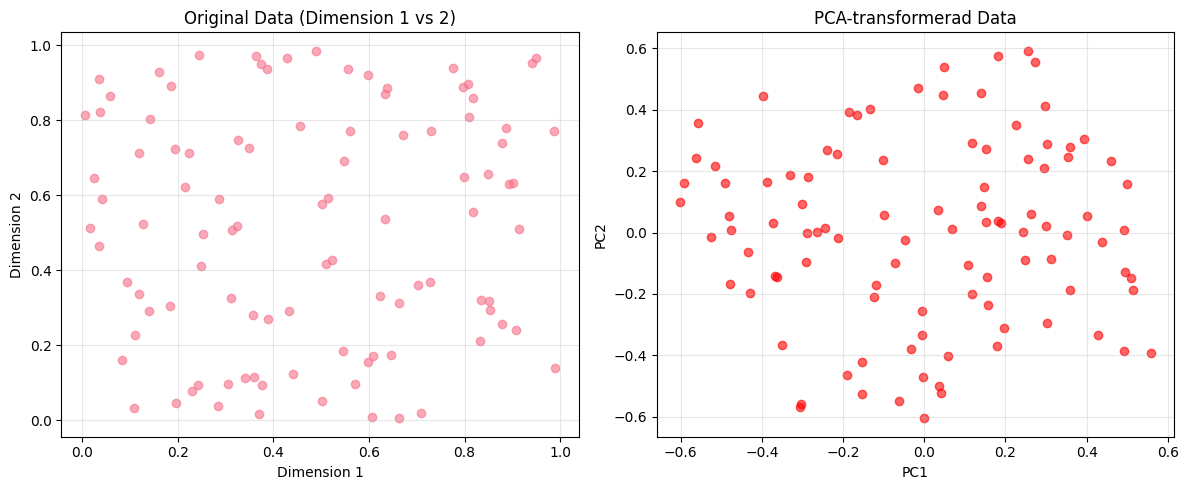

In [4]:
# Skapa en figur med subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original data (första två dimensioner)
axes[0].scatter(X[:, 0], X[:, 1], alpha=0.6)
axes[0].set_title('Original Data (Dimension 1 vs 2)')
axes[0].set_xlabel('Dimension 1')
axes[0].set_ylabel('Dimension 2')
axes[0].grid(True, alpha=0.3)

# PCA-transformerad data
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, color='red')
axes[1].set_title('PCA-transformerad Data')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Iris Dataset - Klassisk PCA-exempel

Vi använder det klassiska Iris-datasetet för att demonstrera PCA.

In [5]:
# Ladda Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names = iris.feature_names

print(f'Iris data shape: {X_iris.shape}')
print(f'Feature names: {feature_names}')
print(f'Target classes: {iris.target_names}')

Iris data shape: (150, 4)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']


In [6]:
# Standardisera data (viktigt för PCA)
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

# Applicera PCA
pca_iris = PCA()
X_iris_pca = pca_iris.fit_transform(X_iris_scaled)

# Visa förklarad varians
explained_variance = pca_iris.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print('Förklarad varians per komponent:')
for i, (var, cum_var) in enumerate(zip(explained_variance, cumulative_variance)):
    print(f'PC{i+1}: {var:.3f} (kumulativ: {cum_var:.3f})')

Förklarad varians per komponent:
PC1: 0.730 (kumulativ: 0.730)
PC2: 0.229 (kumulativ: 0.958)
PC3: 0.037 (kumulativ: 0.995)
PC4: 0.005 (kumulativ: 1.000)


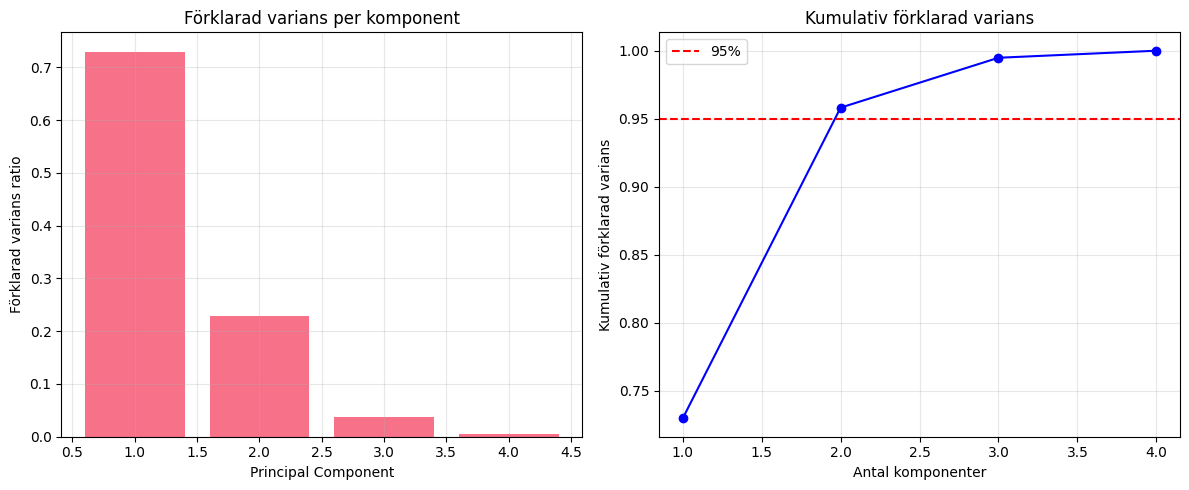

In [7]:
# Visualisera förklarad varians
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Förklarad varians per komponent
axes[0].bar(range(1, len(explained_variance)+1), explained_variance)
axes[0].set_title('Förklarad varians per komponent')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Förklarad varians ratio')
axes[0].grid(True, alpha=0.3)

# Kumulativ förklarad varians
axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'bo-')
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95%')
axes[1].set_title('Kumulativ förklarad varians')
axes[1].set_xlabel('Antal komponenter')
axes[1].set_ylabel('Kumulativ förklarad varians')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. PCA med 2 komponenter för visualisering

Vi reducerar till 2 komponenter för att kunna visualisera data i 2D.

In [8]:
# PCA med 2 komponenter
pca_2d = PCA(n_components=2)
X_iris_2d = pca_2d.fit_transform(X_iris_scaled)

# Skapa DataFrame för enkel hantering
df_pca = pd.DataFrame(X_iris_2d, columns=['PC1', 'PC2'])
df_pca['Species'] = [iris.target_names[i] for i in y_iris]

print(f'Data efter PCA (2D): {X_iris_2d.shape}')
print(f'Förklarad varians: {pca_2d.explained_variance_ratio_.sum():.3f}')
print('\nFörsta 5 rader:')
print(df_pca.head())

Data efter PCA (2D): (150, 2)
Förklarad varians: 0.958

Första 5 rader:
        PC1       PC2 Species
0 -2.264703  0.480027  setosa
1 -2.080961 -0.674134  setosa
2 -2.364229 -0.341908  setosa
3 -2.299384 -0.597395  setosa
4 -2.389842  0.646835  setosa


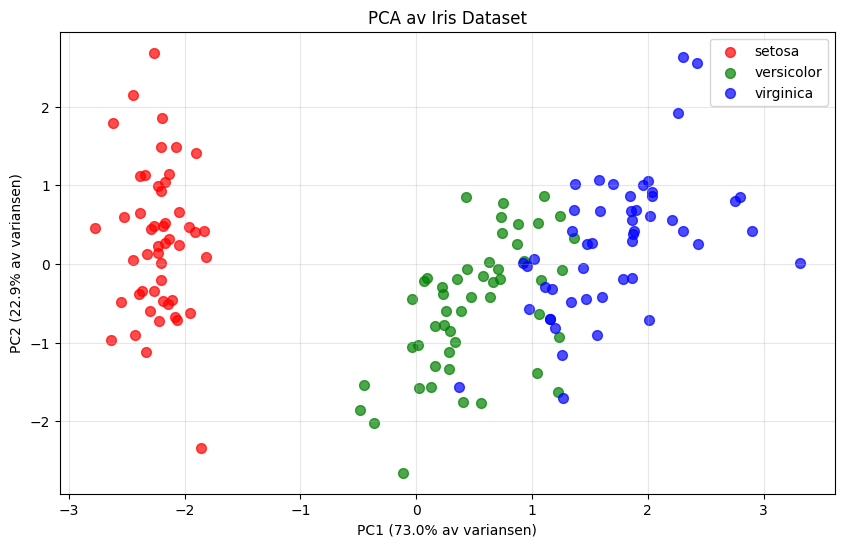

In [9]:
# Visualisera PCA-resultat med färgkodning per art
plt.figure(figsize=(10, 6))
colors = ['red', 'green', 'blue']
species = iris.target_names

for i, (color, specie) in enumerate(zip(colors, species)):
    mask = y_iris == i
    plt.scatter(X_iris_2d[mask, 0], X_iris_2d[mask, 1], 
               c=color, label=specie, alpha=0.7, s=50)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} av variansen)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} av variansen)')
plt.title('PCA av Iris Dataset')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Kernel PCA-exempel

Kernel PCA kan hantera icke-linjära relationer i data.

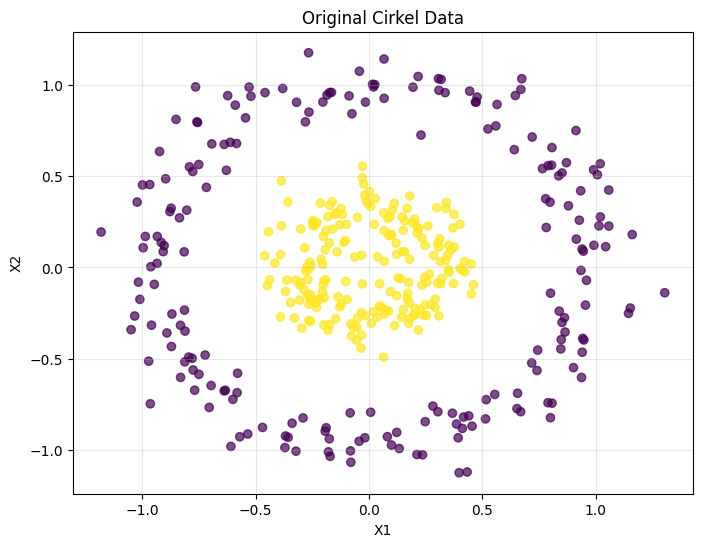

In [10]:
# Skapa icke-linjär data (cirkel)
from sklearn.datasets import make_circles

X_circle, y_circle = make_circles(n_samples=400, noise=0.1, factor=0.3, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(X_circle[:, 0], X_circle[:, 1], c=y_circle, cmap='viridis', alpha=0.7)
plt.title('Original Cirkel Data')
plt.xlabel('X1')
plt.ylabel('X2')
plt.grid(True, alpha=0.3)
plt.show()

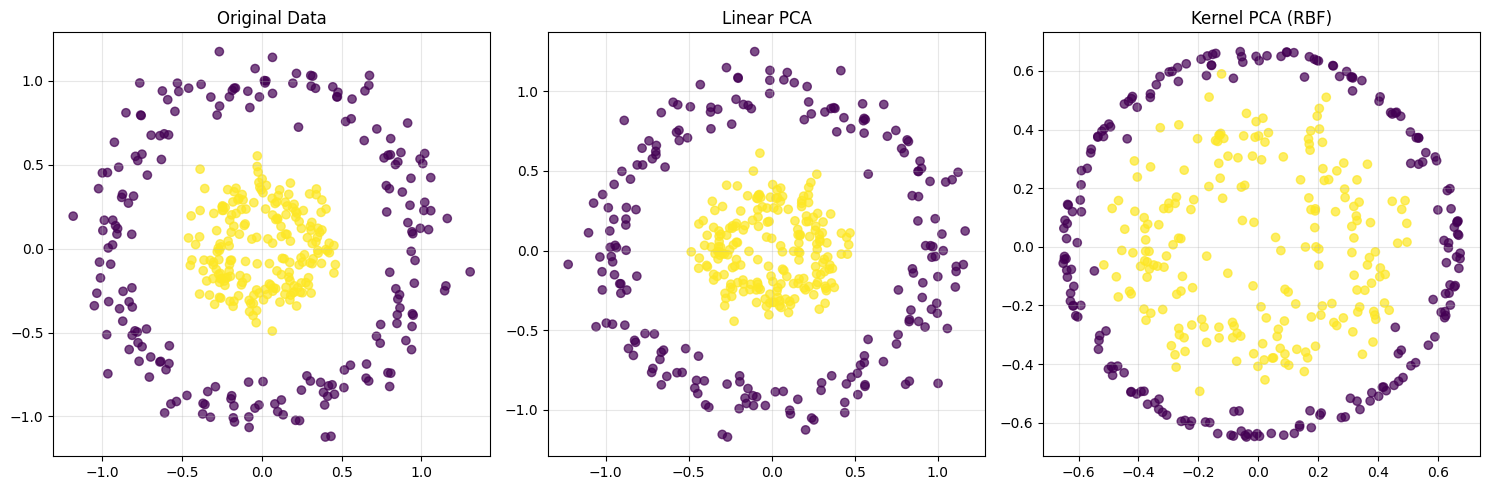

In [11]:
# Jämför vanlig PCA och Kernel PCA
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original data
axes[0].scatter(X_circle[:, 0], X_circle[:, 1], c=y_circle, cmap='viridis', alpha=0.7)
axes[0].set_title('Original Data')
axes[0].grid(True, alpha=0.3)

# Vanlig PCA
pca_linear = PCA(n_components=2)
X_pca_linear = pca_linear.fit_transform(X_circle)
axes[1].scatter(X_pca_linear[:, 0], X_pca_linear[:, 1], c=y_circle, cmap='viridis', alpha=0.7)
axes[1].set_title('Linear PCA')
axes[1].grid(True, alpha=0.3)

# Kernel PCA (RBF)
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=1.0)
X_kpca = kpca.fit_transform(X_circle)
axes[2].scatter(X_kpca[:, 0], X_kpca[:, 1], c=y_circle, cmap='viridis', alpha=0.7)
axes[2].set_title('Kernel PCA (RBF)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. PCA för Machine Learning Pipeline

Vi demonstrerar hur PCA kan användas som preprocessing-steg i en ML-pipeline.

In [12]:
# Dela data i träning och test
X_train, X_test, y_train, y_test = train_test_split(
    X_iris_scaled, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)

print(f'Träningsdata: {X_train.shape}')
print(f'Testdata: {X_test.shape}')

Träningsdata: (105, 4)
Testdata: (45, 4)


In [13]:
# Träna modell utan PCA
lr_original = LogisticRegression(random_state=42)
lr_original.fit(X_train, y_train)
y_pred_original = lr_original.predict(X_test)
accuracy_original = accuracy_score(y_test, y_pred_original)

print(f'Accuracy utan PCA: {accuracy_original:.3f}')
print(f'Antal features: {X_train.shape[1]}')

Accuracy utan PCA: 0.911
Antal features: 4


In [14]:
# Träna modell med PCA (2 komponenter)
pca_ml = PCA(n_components=2)
X_train_pca = pca_ml.fit_transform(X_train)
X_test_pca = pca_ml.transform(X_test)

lr_pca = LogisticRegression(random_state=42)
lr_pca.fit(X_train_pca, y_train)
y_pred_pca = lr_pca.predict(X_test_pca)
accuracy_pca = accuracy_score(y_test, y_pred_pca)

print(f'Accuracy med PCA (2 komponenter): {accuracy_pca:.3f}')
print(f'Antal features: {X_train_pca.shape[1]}')
print(f'Förklarad varians: {pca_ml.explained_variance_ratio_.sum():.3f}')

Accuracy med PCA (2 komponenter): 0.889
Antal features: 2
Förklarad varians: 0.960


## Sammanfattning

I denna notebook har vi gått igenom:

1. **Grundläggande PCA** - Hur man reducerar dimensioner
2. **Förklarad varians** - Hur mycket information som bevaras
3. **Visualisering** - Hur man visualiserar PCA-resultat
4. **Iris dataset** - Klassisk PCA-exempel
5. **Kernel PCA** - För icke-linjära data
6. **ML Pipeline** - PCA som preprocessing-steg

**Viktiga takeaways:**
- PCA reducerar dimensioner genom att hitta huvudkomponenter
- Standardisering är viktigt före PCA
- Förklarad varians hjälper att välja antal komponenter
- PCA kan förbättra prestanda genom att reducera brus